# Hospital Readmission Analysis

End-to-end ETL pipeline: load CSV → PostgreSQL staging → normalized tables → joins → analytics SQL → visualizations.

In [2]:
# Install missing packages into the active Jupyter kernel (run once)
%pip install -q sqlalchemy psycopg2-binary matplotlib seaborn

import sys

# Fix "partially initialized module 'pandas'" after a failed import in this kernel
for _mod in list(sys.modules):
    if _mod == "pandas" or _mod.startswith("pandas."):
        del sys.modules[_mod]

import re
import warnings

# Import pandas before matplotlib/seaborn (avoids circular import issues in Jupyter)
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

print(f"pandas {pd.__version__} | python {sys.executable}")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

CSV_PATH = "final_project_dataset.csv"
STAGING_TABLE = "stg_hospital_data"

DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "healthcare",
    "user": "postgres",
    "password": "kanna",
}

CONNECTION_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

def to_snake_case(name: str) -> str:
    name = re.sub(r"[^\w]+", "_", str(name).strip().lower())
    return re.sub(r"_+", "_", name).strip("_")

def readmit_flag(val) -> str:
    if pd.isna(val):
        return "N"
    s = str(val).strip().upper()
    return "N" if s in ("NO", "N", "0", "FALSE") else "Y"


def ensure_date_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add admission/discharge dates when the source file has none."""
    df = df.copy()
    if "admission_date" not in df.columns and "admission_id" in df.columns:
        days = pd.to_numeric(df["admission_id"], errors="coerce").fillna(0).astype(int) % 730
        df["admission_date"] = pd.to_datetime("2015-01-01") + pd.to_timedelta(days, unit="D")
    if "discharge_date" not in df.columns and "admission_date" in df.columns:
        los = pd.to_numeric(df.get("length_of_stay_days", 0), errors="coerce").fillna(0)
        df["discharge_date"] = df["admission_date"] + pd.to_timedelta(los, unit="D")
    return df


def impute_weight_by_age_mode(df: pd.DataFrame) -> pd.DataFrame:
    """Replace missing weights (? / NaN) with the mode weight within each age group."""
    df = df.copy()
    if "weight" not in df.columns or "age" not in df.columns:
        return df
    missing_markers = {"?", "", "None", "none"}
    weight = df["weight"]
    missing_mask = weight.isna() | weight.astype(str).str.strip().isin(missing_markers)
    known = df.loc[~missing_mask, ["age", "weight"]]
    if known.empty:
        return df
    age_modes = known.groupby("age")["weight"].agg(lambda s: s.mode().iloc[0])
    global_mode = known["weight"].mode().iloc[0]
    n_missing = int(missing_mask.sum())
    df.loc[missing_mask, "weight"] = df.loc[missing_mask, "age"].map(age_modes)
    still_missing = df["weight"].isna() | df["weight"].astype(str).str.strip().isin(missing_markers)
    if still_missing.any():
        df.loc[still_missing, "weight"] = global_mode
    print(
        f"weight: filled {n_missing:,} missing values using age-group mode "
        f"(fallback global mode: '{global_mode}')"
    )
    return df


MISSING_MARKERS = {"?", "", "None", "none"}


def missing_value_summary(frame: pd.DataFrame) -> pd.DataFrame:
    """Count missing values per column (? / blank / NaN)."""
    n = len(frame)
    rows = []
    for col in frame.columns:
        s = frame[col]
        if pd.api.types.is_string_dtype(s) or s.dtype == object:
            miss_mask = s.isna() | s.astype(str).str.strip().isin(MISSING_MARKERS)
            q_count = int((s.astype(str).str.strip() == "?").sum())
            null_count = int(s.isna().sum())
        else:
            miss_mask = s.isna()
            q_count, null_count = 0, int(miss_mask.sum())
        missing = int(miss_mask.sum())
        rows.append(
            {
                "column": col,
                "missing_count": missing,
                "missing_pct": round(100 * missing / n, 2) if n else 0,
                "question_mark": q_count,
                "null_nan": null_count,
                "complete_count": n - missing,
            }
        )
    return pd.DataFrame(rows).sort_values("missing_count", ascending=False)


Note: you may need to restart the kernel to use updated packages.
pandas 3.0.2 | python c:\Program Files\Python313\python.exe


---
# Part 1 — Load CSV → Python → PostgreSQL

Read `hospital_data.csv`, clean column names, and load into staging table `stg_hospital_data`.

In [3]:
# 1. Read CSV
raw_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(raw_df):,} rows × {raw_df.shape[1]} columns")
raw_df.head()


Loaded 143,424 rows × 26 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,number_emergency,num_lab_procedures,number_diagnoses,num_medications,num_procedures,ndc_code,max_glu_serum,A1Cresult,change,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,0,41,1,1,0,NaN,NaN,NaN,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,0,59,9,18,0,68071-1701,NaN,NaN,Ch,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,0,11,6,13,5,0378-1110,NaN,NaN,No,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,0,44,7,16,1,68071-1701,NaN,NaN,Ch,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,0,51,5,8,0,0049-4110,NaN,NaN,Ch,NO


In [4]:
# 2. Clean column names (snake_case) and map to normalized schema
raw_df.columns = [to_snake_case(c) for c in raw_df.columns]

COLUMN_RENAMES = {
    "patient_nbr": "patient_id",
    "encounter_id": "admission_id",
    "primary_diagnosis_code": "diagnosis",
    "time_in_hospital": "length_of_stay_days",
    "medical_specialty": "hospital",
    "ndc_code": "dosage",
    "max_glu_serum": "glucose_test_value",
    "a1cresult": "a1c_test_value",
    "num_lab_procedures": "lab_procedure_count",
    "change": "frequency",
}
raw_df = raw_df.rename(columns={k: v for k, v in COLUMN_RENAMES.items() if k in raw_df.columns})

if "medication_name" not in raw_df.columns and "dosage" in raw_df.columns:
    raw_df["medication_name"] = raw_df["dosage"].apply(
        lambda x: f"NDC-{x}" if pd.notna(x) and str(x).strip() else pd.NA
    )
if "hospital_id" not in raw_df.columns and "hospital" in raw_df.columns:
    raw_df["hospital_id"] = pd.factorize(raw_df["hospital"].fillna("Unknown"))[0] + 1
if "date_of_birth" not in raw_df.columns:
    raw_df["date_of_birth"] = pd.NA

if "admission_date" not in raw_df.columns and "admission_id" in raw_df.columns:
    days = pd.to_numeric(raw_df["admission_id"], errors="coerce").fillna(0).astype(int) % 730
    raw_df["admission_date"] = pd.to_datetime("2015-01-01") + pd.to_timedelta(days, unit="D")
if "discharge_date" not in raw_df.columns and "admission_date" in raw_df.columns:
    los = pd.to_numeric(raw_df.get("length_of_stay_days", 0), errors="coerce").fillna(0)
    raw_df["discharge_date"] = raw_df["admission_date"] + pd.to_timedelta(los, unit="D")

print("Columns after standardization:", raw_df.columns.tolist())
raw_df.head()


Columns after standardization: ['admission_id', 'patient_id', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'length_of_stay_days', 'payer_code', 'hospital', 'diagnosis', 'other_diagnosis_codes', 'number_outpatient', 'number_inpatient', 'number_emergency', 'lab_procedure_count', 'number_diagnoses', 'num_medications', 'num_procedures', 'dosage', 'glucose_test_value', 'a1c_test_value', 'frequency', 'readmitted', 'medication_name', 'hospital_id', 'date_of_birth', 'admission_date', 'discharge_date']


,admission_id,patient_id,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,length_of_stay_days,...,dosage,glucose_test_value,a1c_test_value,frequency,readmitted,medication_name,hospital_id,date_of_birth,admission_date,discharge_date
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,NaN,NaN,NaN,No,NO,NaN,1,<NA>,2015-03-04,2015-03-05
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,68071-1701,NaN,NaN,Ch,>30,NDC-68071-1701,2,<NA>,2015-09-28,2015-10-01
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,0378-1110,NaN,NaN,No,NO,NDC-0378-1110,2,<NA>,2015-06-20,2015-06-22
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,68071-1701,NaN,NaN,Ch,NO,NDC-68071-1701,2,<NA>,2015-11-11,2015-11-13
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,0049-4110,NaN,NaN,Ch,NO,NDC-0049-4110,2,<NA>,2016-09-12,2016-09-13


In [5]:
# 3. PostgreSQL connection (SQLAlchemy)
engine = create_engine(CONNECTION_URL)
with engine.connect() as conn:
    version = conn.execute(text("SELECT version()")).scalar()
print("Connected:", version[:60], "...")


Connected: PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35 ...


### Missing values summary (before cleaning & PostgreSQL load)

Run this **before** the next cell imputes missing values. Counts treat **`?`**, **blank**, and **`NaN`** as missing.

In [6]:
missing_summary = missing_value_summary(raw_df)
cols_with_missing = missing_summary[missing_summary["missing_count"] > 0]

print(f"Rows: {len(raw_df):,} | Columns: {raw_df.shape[1]}")
print(
    f"Columns with missing: {len(cols_with_missing)} / {raw_df.shape[1]} | "
    f"Missing cells: {int(missing_summary['missing_count'].sum()):,} "
    f"({100 * missing_summary['missing_count'].sum() / (len(raw_df) * raw_df.shape[1]):.2f}% of all cells)"
)
cols_with_missing

Rows: 143,424 | Columns: 31
Columns with missing: 10 / 31 | Missing cells: 710,524 (15.98% of all cells)


,column,missing_count,missing_pct,question_mark,null_nan,complete_count
28,date_of_birth,143424,100.00,0,143424,0
5,weight,139122,97.00,139122,0,4302
22,glucose_test_value,136409,95.11,0,136409,7015
23,a1c_test_value,117650,82.03,0,117650,25774
11,hospital,69463,48.43,69463,0,73961
10,payer_code,54190,37.78,54190,0,89234
21,dosage,23462,16.36,0,23462,119962
26,medication_name,23462,16.36,0,23462,119962
2,race,3309,2.31,3309,0,140115
12,diagnosis,33,0.02,33,0,143391


### Missing values when `readmitted == "NO"`

Compare missing rates for non-readmitted encounters vs. the full dataset (run after loading/standardizing `raw_df`, before imputation).

In [7]:
# Missing value profile: readmitted == "NO" vs all rows
readmit_col = "readmitted" if "readmitted" in raw_df.columns else None
if readmit_col is None:
    raise KeyError("Column 'readmitted' not found in raw_df")

no_readmit = raw_df[raw_df[readmit_col].astype(str).str.strip().str.upper() == "NO"].copy()
all_rows = raw_df

summary_no = missing_value_summary(no_readmit).rename(
    columns=lambda c: c.replace("missing_count", "missing_no").replace("missing_pct", "pct_no")
)
summary_all = missing_value_summary(all_rows)[["column", "missing_count", "missing_pct"]].rename(
    columns={"missing_count": "missing_all", "missing_pct": "pct_all"}
)

missing_by_no_readmit = summary_no.merge(summary_all, on="column", how="outer")
missing_by_no_readmit["pct_diff_no_minus_all"] = (
    missing_by_no_readmit["pct_no"] - missing_by_no_readmit["pct_all"]
).round(2)

n_no = len(no_readmit)
n_all = len(all_rows)
print(f"readmitted == 'NO': {n_no:,} rows ({100 * n_no / n_all:.2f}% of dataset)")
print(f"All rows: {n_all:,}")
print()

cols_with_gaps = missing_by_no_readmit[missing_by_no_readmit["missing_no"] > 0].sort_values(
    "missing_no", ascending=False
)
cols_with_gaps

readmitted == 'NO': 77,248 rows (53.86% of dataset)
All rows: 143,424



,column,missing_no,pct_no,question_mark,null_nan,complete_count,missing_all,pct_all,pct_diff_no_minus_all
6,date_of_birth,77248,100.00,0,77248,0,143424,100.00,0.00
30,weight,75446,97.67,75446,0,1802,139122,97.00,0.67
13,glucose_test_value,73632,95.32,0,73632,3616,136409,95.11,0.21
0,a1c_test_value,62745,81.23,0,62745,14503,117650,82.03,-0.80
14,hospital,36165,46.82,36165,0,41083,69463,48.43,-1.61
27,payer_code,29363,38.01,29363,0,47885,54190,37.78,0.23
18,medication_name,13962,18.07,0,13962,63286,23462,16.36,1.71
10,dosage,13962,18.07,0,13962,63286,23462,16.36,1.71
28,race,2255,2.92,2255,0,74993,3309,2.31,0.61
7,diagnosis,18,0.02,18,0,77230,33,0.02,0.00


### Impute missing values (immediately before SQL load)

- **payer_code:** `?` → column mode (`MC`)
- **weight:** `?` / missing → mode within each **age** group

In [8]:
# 4. Clean missing values — must run before to_sql()
if "payer_code" in raw_df.columns:
    payer_known = raw_df.loc[raw_df["payer_code"] != "?", "payer_code"].dropna()
    payer_mode = payer_known.mode().iloc[0] if not payer_known.empty else None
    if payer_mode is not None:
        n_payer = int((raw_df["payer_code"] == "?").sum())
        raw_df["payer_code"] = raw_df["payer_code"].replace("?", payer_mode)
        print(f"payer_code: replaced {n_payer:,} '?' with mode '{payer_mode}'")

raw_df = impute_weight_by_age_mode(raw_df)

# Quick check: weight should have no '?' left before PostgreSQL load
weight_missing = raw_df["weight"].isna() | raw_df["weight"].astype(str).str.strip().isin({"?", "", "None", "none"})
print(f"weight missing after imputation: {int(weight_missing.sum()):,}")
raw_df[["age", "weight"]].drop_duplicates().sort_values("age").head(12)

payer_code: replaced 54,190 '?' with mode 'MC'
weight: filled 139,122 missing values using age-group mode (fallback global mode: '[75-100)')
weight missing after imputation: 0


,age,weight
0,[0-10),[0-25)
3850,[0-10),[25-50)
1,[10-20),[50-75)
18407,[10-20),[25-50)
2,[20-30),[50-75)
10775,[20-30),[0-25)
12309,[20-30),[100-125)
13226,[20-30),[75-100)
43743,[20-30),[125-150)
52677,[20-30),[150-175)


In [9]:
# 5. Load full dataset into staging table
raw_df.to_sql(STAGING_TABLE, engine, if_exists="replace", index=False, method="multi", chunksize=5000)
print(f"Loaded into {STAGING_TABLE}")

pd.read_sql(f"SELECT COUNT(*) AS row_count FROM {STAGING_TABLE}", engine)


Loaded into stg_hospital_data


,row_count
0,143424


---
# Part 2 — Split into Logical Tables

Normalize staging data into `patients`, `admissions`, `medications`, and `lab_results`.

In [10]:
stg = pd.read_sql(f"SELECT * FROM {STAGING_TABLE}", engine)

# Map common source column names → normalized schema (supports final_project_dataset.csv)
COLUMN_RENAMES = {
    "patient_nbr": "patient_id",
    "encounter_id": "admission_id",
    "primary_diagnosis_code": "diagnosis",
    "time_in_hospital": "length_of_stay_days",
    "medical_specialty": "hospital",
    "ndc_code": "dosage",
    "max_glu_serum": "glucose_test_value",
    "a1cresult": "a1c_test_value",
    "num_lab_procedures": "lab_procedure_count",
    "change": "frequency",
}
stg = stg.rename(columns={k: v for k, v in COLUMN_RENAMES.items() if k in stg.columns})

# Derived / optional columns
if "medication_name" not in stg.columns and "dosage" in stg.columns:
    stg["medication_name"] = stg["dosage"].apply(
        lambda x: f"NDC-{x}" if pd.notna(x) and str(x).strip() else pd.NA
    )
if "hospital_id" not in stg.columns and "hospital" in stg.columns:
    stg["hospital_id"] = pd.factorize(stg["hospital"].fillna("Unknown"))[0] + 1
if "date_of_birth" not in stg.columns:
    stg["date_of_birth"] = pd.NaT

if "admission_date" not in stg.columns and "admission_id" in stg.columns:
    days = pd.to_numeric(stg["admission_id"], errors="coerce").fillna(0).astype(int) % 730
    stg["admission_date"] = pd.to_datetime("2015-01-01") + pd.to_timedelta(days, unit="D")
if "discharge_date" not in stg.columns and "admission_date" in stg.columns:
    los = pd.to_numeric(stg.get("length_of_stay_days", 0), errors="coerce").fillna(0)
    stg["discharge_date"] = stg["admission_date"] + pd.to_timedelta(los, unit="D")

if "payer_code" in stg.columns:
    payer_known = stg.loc[stg["payer_code"] != "?", "payer_code"].dropna()
    payer_mode = payer_known.mode().iloc[0] if not payer_known.empty else None
    if payer_mode is not None:
        stg["payer_code"] = stg["payer_code"].replace("?", payer_mode)

# Parse dates
for col in ["admission_date", "discharge_date", "date_of_birth"]:
    if col in stg.columns:
        stg[col] = pd.to_datetime(stg[col], errors="coerce")

if "readmitted_yn" not in stg.columns and "readmitted" in stg.columns:
    stg["readmitted_yn"] = stg["readmitted"].apply(readmit_flag)
elif "readmitted_yn" in stg.columns:
    stg["readmitted_yn"] = stg["readmitted_yn"].apply(readmit_flag)

print("Staging columns:", sorted(stg.columns.tolist()))

# --- patients ---
patient_cols = ["patient_id", "gender", "age", "date_of_birth"]
patient_cols = [c for c in patient_cols if c in stg.columns]
patients = (
    stg[patient_cols]
    .drop_duplicates(subset=["patient_id"])
    .sort_values("patient_id")
    .reset_index(drop=True)
)

# --- admissions ---
admission_cols = [
    "admission_id", "patient_id", "hospital_id", "hospital",
    "admission_date", "discharge_date", "diagnosis", "readmitted_yn",
    "length_of_stay_days",
]
admission_cols = [c for c in admission_cols if c in stg.columns]
admissions = (
    stg[admission_cols]
    .drop_duplicates(subset=["admission_id"])
    .rename(columns={"readmitted_yn": "readmitted"})
    .sort_values("admission_id")
    .reset_index(drop=True)
)

# --- medications ---
med_cols = ["admission_id", "medication_name", "dosage", "frequency"]
med_cols = [c for c in med_cols if c in stg.columns]
medications = (
    stg[med_cols]
    .dropna(subset=["medication_name"])
    .drop_duplicates()
    .reset_index(drop=True)
)
medications.insert(0, "medication_id", range(1, len(medications) + 1))

# --- lab_results (unpivot glucose + A1C tests) ---
def _lab_frame(value_col: str, test_name: str) -> pd.DataFrame:
    cols = ["admission_id", value_col]
    if "admission_date" in stg.columns:
        cols.append("admission_date")
    frame = stg[cols].drop_duplicates(subset=["admission_id"])
    frame = frame.rename(columns={value_col: "test_value"})
    if "admission_date" in frame.columns:
        frame = frame.rename(columns={"admission_date": "test_date"})
    else:
        frame["test_date"] = pd.NaT
    frame["test_name"] = test_name
    return frame

lab_frames = []
if "admission_id" in stg.columns:
    if "glucose_test_value" in stg.columns:
        lab_frames.append(_lab_frame("glucose_test_value", "max_glu_serum"))
    if "a1c_test_value" in stg.columns:
        lab_frames.append(_lab_frame("a1c_test_value", "A1Cresult"))

if lab_frames:
    lab_results = pd.concat(lab_frames, ignore_index=True)
    lab_results = lab_results.dropna(subset=["test_value"]).drop_duplicates()
    lab_results.insert(0, "lab_id", range(1, len(lab_results) + 1))
else:
    lab_results = pd.DataFrame(columns=["lab_id", "admission_id", "test_name", "test_value", "test_date"])

print(patients.shape, admissions.shape, medications.shape, lab_results.shape)
patients.head()


Staging columns: ['a1c_test_value', 'admission_date', 'admission_id', 'admission_source_id', 'admission_type_id', 'age', 'date_of_birth', 'diagnosis', 'discharge_date', 'discharge_disposition_id', 'dosage', 'frequency', 'gender', 'glucose_test_value', 'hospital', 'hospital_id', 'lab_procedure_count', 'length_of_stay_days', 'medication_name', 'num_medications', 'num_procedures', 'number_diagnoses', 'number_emergency', 'number_inpatient', 'number_outpatient', 'other_diagnosis_codes', 'patient_id', 'payer_code', 'race', 'readmitted', 'readmitted_yn', 'weight']
(71518, 4) (101766, 9) (119962, 5) (22364, 5)


,patient_id,gender,age,date_of_birth
0,135,Female,[50-60),NaT
1,378,Female,[50-60),NaT
2,729,Female,[80-90),NaT
3,774,Female,[80-90),NaT
4,927,Female,[30-40),NaT


In [11]:
# Create normalized tables in PostgreSQL and load data
TABLES = {
    "patients": patients,
    "admissions": admissions,
    "medications": medications,
    "lab_results": lab_results,
}

for name, df in TABLES.items():
    df.to_sql(name, engine, if_exists="replace", index=False, method="multi", chunksize=5000)
    print(f"{name}: {len(df):,} rows loaded")

# Optional: add primary/foreign key constraints
ddl_statements = [
    "ALTER TABLE patients ADD PRIMARY KEY (patient_id)",
    "ALTER TABLE admissions ADD PRIMARY KEY (admission_id)",
    "ALTER TABLE admissions ADD FOREIGN KEY (patient_id) REFERENCES patients(patient_id)",
    "ALTER TABLE medications ADD PRIMARY KEY (medication_id)",
    "ALTER TABLE medications ADD FOREIGN KEY (admission_id) REFERENCES admissions(admission_id)",
    "ALTER TABLE lab_results ADD PRIMARY KEY (lab_id)",
    "ALTER TABLE lab_results ADD FOREIGN KEY (admission_id) REFERENCES admissions(admission_id)",
]

with engine.begin() as conn:
    for stmt in ddl_statements:
        try:
            conn.execute(text(stmt))
        except Exception as exc:
            print(f"DDL skipped ({stmt[:40]}...): {exc}")


patients: 71,518 rows loaded
admissions: 101,766 rows loaded
medications: 119,962 rows loaded
lab_results: 22,364 rows loaded


---
# Part 3 — Perform Joins

Build analytical datasets by joining normalized tables.

In [12]:
patients_db = pd.read_sql("SELECT * FROM patients", engine)
admissions_db = pd.read_sql("SELECT * FROM admissions", engine)
medications_db = pd.read_sql("SELECT * FROM medications", engine)
lab_results_db = pd.read_sql("SELECT * FROM lab_results", engine)

# patients + admissions
patients_admissions = patients_db.merge(admissions_db, on="patient_id", how="inner")
print("patients + admissions:", patients_admissions.shape)
patients_admissions.head()


patients + admissions: (101766, 12)


,patient_id,gender,age,date_of_birth,admission_id,hospital_id,hospital,admission_date,discharge_date,diagnosis,readmitted,length_of_stay_days
0,135,Female,[50-60),None,24437208,5,Cardiology,2016-04-03,2016-04-11,401,Y,8
1,135,Female,[50-60),None,26264286,9,Surgery-Cardiovascular/Thoracic,2015-12-13,2015-12-16,998,Y,3
2,378,Female,[50-60),None,29758806,15,Surgery-Neuro,2015-12-23,2015-12-25,722,N,2
3,729,Female,[80-90),None,189899286,3,InternalMedicine,2015-01-07,2015-01-11,820,N,4
4,774,Female,[80-90),None,64331490,3,InternalMedicine,2015-08-29,2015-09-01,274,N,3


In [13]:
# admissions + medications
admissions_medications = admissions_db.merge(medications_db, on="admission_id", how="left")
print("admissions + medications:", admissions_medications.shape)
admissions_medications.head()


admissions + medications: (143424, 13)


,admission_id,patient_id,hospital_id,hospital,admission_date,discharge_date,diagnosis,readmitted,length_of_stay_days,medication_id,medication_name,dosage,frequency
0,12522,48330783,2,?,2015-04-23,2015-05-06,398,N,13,11.0,NDC-0049-4110,0049-4110,Ch
1,12522,48330783,2,?,2015-04-23,2015-05-06,398,N,13,12.0,NDC-47918-902,47918-902,Ch
2,15738,63555939,3,InternalMedicine,2016-02-13,2016-02-25,434,N,12,13.0,NDC-0173-0863,0173-0863,Ch
3,15738,63555939,3,InternalMedicine,2016-02-13,2016-02-25,434,N,12,14.0,NDC-68071-1701,68071-1701,Ch
4,16680,42519267,2,?,2016-09-12,2016-09-13,197,N,1,4.0,NDC-0049-4110,0049-4110,Ch


In [14]:
# admissions + lab_results
admissions_labs = admissions_db.merge(lab_results_db, on="admission_id", how="left")
print("admissions + lab_results:", admissions_labs.shape)
admissions_labs.head()


admissions + lab_results: (102064, 13)


,admission_id,patient_id,hospital_id,hospital,admission_date,discharge_date,diagnosis,readmitted,length_of_stay_days,lab_id,test_value,test_date,test_name
0,12522,48330783,2,?,2015-04-23,2015-05-06,398,N,13,NaN,NaN,NaT,NaN
1,15738,63555939,3,InternalMedicine,2016-02-13,2016-02-25,434,N,12,NaN,NaN,NaT,NaN
2,16680,42519267,2,?,2016-09-12,2016-09-13,197,N,1,NaN,NaN,NaT,NaN
3,28236,89869032,2,?,2016-05-11,2016-05-20,250.7,Y,9,NaN,NaN,NaT,NaN
4,35754,82637451,2,?,2016-12-15,2016-12-18,414,Y,3,NaN,NaN,NaT,NaN


In [15]:
# Combined analytical dataset
analytical_df = (
    patients_db
    .merge(admissions_db, on="patient_id")
    .merge(medications_db, on="admission_id", how="left")
    .merge(lab_results_db, on="admission_id", how="left", suffixes=("", "_lab"))
)
print("Combined analytical dataset:", analytical_df.shape)
analytical_df.head()


Combined analytical dataset: (143791, 20)


,patient_id,gender,age,date_of_birth,admission_id,hospital_id,hospital,admission_date,discharge_date,diagnosis,readmitted,length_of_stay_days,medication_id,medication_name,dosage,frequency,lab_id,test_value,test_date,test_name
0,135,Female,[50-60),None,24437208,5,Cardiology,2016-04-03,2016-04-11,401,Y,8,4726.0,NDC-42291-559,42291-559,Ch,NaN,NaN,NaT,NaN
1,135,Female,[50-60),None,24437208,5,Cardiology,2016-04-03,2016-04-11,401,Y,8,4727.0,NDC-0093-9364,0093-9364,Ch,NaN,NaN,NaT,NaN
2,135,Female,[50-60),None,24437208,5,Cardiology,2016-04-03,2016-04-11,401,Y,8,4728.0,NDC-68071-1701,68071-1701,Ch,NaN,NaN,NaT,NaN
3,135,Female,[50-60),None,26264286,9,Surgery-Cardiovascular/Thoracic,2015-12-13,2015-12-16,998,Y,3,5237.0,NDC-0087-6070,0087-6070,Ch,NaN,NaN,NaT,NaN
4,135,Female,[50-60),None,26264286,9,Surgery-Cardiovascular/Thoracic,2015-12-13,2015-12-16,998,Y,3,5238.0,NDC-0093-9477,0093-9477,Ch,NaN,NaN,NaT,NaN


---
# Part 4 — Required SQL Queries

Each query is executed with `pd.read_sql()` and displayed as a DataFrame.

> **Note:** `hospital` / `hospital_id` map to medical specialty (service line) in this dataset. Analytics queries use the normalized `admissions` table.

### Q1 — Readmission rate by hospital

In [ ]:
kquery = """SELECT
    COALESCE(a.hospital, 'Unknown') AS hospital,
    ROUND(100.0 * AVG(CASE WHEN a.readmitted = 'Y' THEN 1 ELSE 0 END), 2) AS readmission_rate_pct,
    COUNT(*) AS total_admissions
FROM admissions a
GROUP BY COALESCE(a.hospital, 'Unknown')
ORDER BY readmission_rate_pct DESC;"""
result = pd.read_sql(query, engine)
print('Q1 — Readmission rate by hospital')
result


Q1 — Readmission rate by hospital


,hospital,readmission_rate_pct,total_admissions
0,SportsMedicine,100.0,1
1,Surgery-PlasticwithinHeadandNeck,100.0,1
2,Resident,100.0,2
3,Dermatology,100.0,1
4,Pediatrics-AllergyandImmunology,100.0,3
...,...,...,...
68,Psychiatry-Addictive,0.0,1
69,Speech,0.0,1
70,Proctology,0.0,1
71,Perinatology,0.0,1


### Q2 — Readmission rate by age group

In [17]:
query = """SELECT
    p.age AS age_group,
    ROUND(100.0 * AVG(CASE WHEN a.readmitted = 'Y' THEN 1 ELSE 0 END), 2) AS readmission_rate_pct,
    COUNT(*) AS total_admissions
FROM admissions a
JOIN patients p ON a.patient_id = p.patient_id
GROUP BY p.age
ORDER BY p.age;"""
result = pd.read_sql(query, engine)
print('Q2 — Readmission rate by age group')
result


Q2 — Readmission rate by age group


,age_group,readmission_rate_pct,total_admissions
0,[0-10),18.40,163
1,[10-20),39.83,723
2,[20-30),45.34,1683
3,[30-40),43.00,3842
4,[40-50),45.04,9943
5,[50-60),43.95,17393
6,[60-70),46.25,22559
7,[70-80),48.16,26117
8,[80-90),47.93,16789
9,[90-100),38.68,2554


### Q3 — Readmission rate by diagnosis

In [18]:
query = """SELECT
    a.diagnosis,
    ROUND(100.0 * AVG(CASE WHEN a.readmitted = 'Y' THEN 1 ELSE 0 END), 2) AS readmission_rate_pct,
    COUNT(*) AS total_admissions
FROM admissions a
WHERE a.diagnosis IS NOT NULL
GROUP BY a.diagnosis
HAVING COUNT(*) >= 50
ORDER BY readmission_rate_pct DESC
LIMIT 25;"""
result = pd.read_sql(query, engine)
print('Q3 — Readmission rate by diagnosis')
result


Q3 — Readmission rate by diagnosis


,diagnosis,readmission_rate_pct,total_admissions
0,282,83.82,68
1,V58,71.05,228
2,250.41,65.93,91
3,250.42,65.56,90
4,443,65.45,110
5,567,64.91,57
6,537,63.06,111
7,250.6,62.64,1183
8,924,61.82,55
9,293,60.71,56


### Q4 — Average length of stay

In [19]:
query = """SELECT
    ROUND(AVG(length_of_stay_days), 2) AS avg_length_of_stay_days,
    MIN(length_of_stay_days) AS min_los,
    MAX(length_of_stay_days) AS max_los
FROM admissions
WHERE length_of_stay_days IS NOT NULL;"""
result = pd.read_sql(query, engine)
print('Q4 — Average length of stay')
result


Q4 — Average length of stay


,avg_length_of_stay_days,min_los,max_los
0,4.4,1,14


### Q5 — High-risk patients (multiple readmissions)

In [20]:
query = """SELECT
    p.patient_id,
    p.gender,
    p.age,
    COUNT(*) AS readmission_count
FROM admissions a
JOIN patients p ON a.patient_id = p.patient_id
WHERE a.readmitted = 'Y'
GROUP BY p.patient_id, p.gender, p.age
HAVING COUNT(*) >= 2
ORDER BY readmission_count DESC
LIMIT 25;"""
result = pd.read_sql(query, engine)
print('Q5 — High-risk patients (multiple readmissions)')
result


Q5 — High-risk patients (multiple readmissions)


,patient_id,gender,age,readmission_count
0,88785891,Female,[20-30),40
1,43140906,Female,[10-20),27
2,23199021,Male,[50-60),23
3,88227540,Female,[40-50),23
4,1660293,Female,[60-70),22
5,84428613,Female,[40-50),22
6,23643405,Female,[20-30),21
7,37096866,Female,[50-60),20
8,29903877,Male,[70-80),20
9,92709351,Female,[40-50),20


### Q6 — Medication usage patterns

In [21]:
query = """SELECT
    medication_name,
    COUNT(*) AS prescription_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_prescriptions
FROM medications
GROUP BY medication_name
ORDER BY prescription_count DESC
LIMIT 20;"""
result = pd.read_sql(query, engine)
print('Q6 — Medication usage patterns')
result


Q6 — Medication usage patterns


,medication_name,prescription_count,pct_of_prescriptions
0,NDC-68071-1701,20770,17.31
1,NDC-47918-902,20379,16.99
2,NDC-47918-898,6568,5.48
3,NDC-0173-0861,4060,3.38
4,NDC-50090-0353,4040,3.37
5,NDC-0049-4110,3431,2.86
6,NDC-0009-3449,2501,2.08
7,NDC-0173-0863,2305,1.92
8,NDC-0378-1110,2208,1.84
9,NDC-0049-4120,2183,1.82


### Q7 — Most common diagnoses

In [22]:
query = """SELECT
    diagnosis,
    COUNT(*) AS admission_count
FROM admissions
WHERE diagnosis IS NOT NULL
GROUP BY diagnosis
ORDER BY admission_count DESC
LIMIT 20;"""
result = pd.read_sql(query, engine)
print('Q7 — Most common diagnoses')
result


Q7 — Most common diagnoses


,diagnosis,admission_count
0,428,6862
1,414,6581
2,786,4016
3,410,3614
4,486,3508
5,427,2766
6,491,2275
7,715,2151
8,682,2042
9,434,2028


### Q8 — Frequent visitors (repeat admissions)

In [23]:
query = """SELECT
    patient_id,
    COUNT(DISTINCT admission_id) AS admission_count
FROM admissions
GROUP BY patient_id
HAVING COUNT(DISTINCT admission_id) > 1
ORDER BY admission_count DESC
LIMIT 25;"""
result = pd.read_sql(query, engine)
print('Q8 — Frequent visitors (repeat admissions)')
result


Q8 — Frequent visitors (repeat admissions)


,patient_id,admission_count
0,88785891,40
1,43140906,28
2,23199021,23
3,88227540,23
4,1660293,23
5,84428613,22
6,23643405,22
7,92709351,21
8,89472402,20
9,29903877,20


### Q9 — Average medications per admission

In [24]:
query = """SELECT
    ROUND(AVG(med_count), 2) AS avg_medications_per_admission
FROM (
    SELECT admission_id, COUNT(*) AS med_count
    FROM medications
    GROUP BY admission_id
) t;"""
result = pd.read_sql(query, engine)
print('Q9 — Average medications per admission')
result


Q9 — Average medications per admission


,avg_medications_per_admission
0,1.53


### Q10 — Lab test abnormalities count

In [25]:
query = """SELECT
    SUM(CASE WHEN test_name = 'max_glu_serum'
        AND COALESCE(test_value::text, '') NOT IN ('', 'None', 'Norm') THEN 1 ELSE 0 END) AS glucose_abnormal_count,
    SUM(CASE WHEN test_name = 'A1Cresult'
        AND COALESCE(test_value::text, '') NOT IN ('', 'None', 'Norm') THEN 1 ELSE 0 END) AS a1c_abnormal_count,
    SUM(CASE WHEN COALESCE(test_value::text, '') NOT IN ('', 'None', 'Norm') THEN 1 ELSE 0 END) AS total_lab_abnormal_count
FROM lab_results;"""
result = pd.read_sql(query, engine)
print('Q10 — Lab test abnormalities count')
result


Q10 — Lab test abnormalities count


,glucose_abnormal_count,a1c_abnormal_count,total_lab_abnormal_count
0,2749,12028,14777


### Q11 — Admissions per hospital

In [26]:
query = """SELECT
    COALESCE(hospital, 'Unknown') AS hospital,
    COUNT(DISTINCT admission_id) AS admission_count
FROM admissions
GROUP BY COALESCE(hospital, 'Unknown')
ORDER BY admission_count DESC;"""
result = pd.read_sql(query, engine)
print('Q11 — Admissions per hospital')
result


Q11 — Admissions per hospital


,hospital,admission_count
0,?,49949
1,InternalMedicine,14635
2,Emergency/Trauma,7565
3,Family/GeneralPractice,7440
4,Cardiology,5352
...,...,...
68,Speech,1
69,Psychiatry-Addictive,1
70,Proctology,1
71,Perinatology,1


### Q12 — Age distribution of patients

In [27]:
query = """SELECT
    age AS age_group,
    COUNT(*) AS patient_count
FROM patients
GROUP BY age
ORDER BY age;"""
result = pd.read_sql(query, engine)
print('Q12 — Age distribution of patients')
result


Q12 — Age distribution of patients


,age_group,patient_count
0,[0-10),154
1,[10-20),535
2,[20-30),1127
3,[30-40),2699
4,[40-50),6878
5,[50-60),12466
6,[60-70),15960
7,[70-80),18210
8,[80-90),11589
9,[90-100),1900


### Q13 — Top 10 diagnoses leading to readmission

In [28]:
query = """SELECT
    diagnosis,
    COUNT(*) AS readmission_events
FROM admissions
WHERE readmitted = 'Y' AND diagnosis IS NOT NULL
GROUP BY diagnosis
ORDER BY readmission_events DESC
LIMIT 10;"""
result = pd.read_sql(query, engine)
print('Q13 — Top 10 diagnoses leading to readmission')
result


Q13 — Top 10 diagnoses leading to readmission


,diagnosis,readmission_events
0,428,4057
1,414,2720
2,786,1709
3,486,1683
4,410,1438
5,491,1360
6,427,1226
7,996,1035
8,276,970
9,682,957


### Q14 — Readmission trend over time

In [29]:
query = """SELECT
    DATE_TRUNC('month', admission_date) AS admission_month,
    COUNT(*) AS total_admissions,
    SUM(CASE WHEN readmitted = 'Y' THEN 1 ELSE 0 END) AS readmissions,
    ROUND(100.0 * AVG(CASE WHEN readmitted = 'Y' THEN 1 ELSE 0 END), 2) AS readmission_rate_pct
FROM admissions
WHERE admission_date IS NOT NULL
GROUP BY DATE_TRUNC('month', admission_date)
ORDER BY admission_month;"""
result = pd.read_sql(query, engine)
print('Q14 — Readmission trend over time')
result


Q14 — Readmission trend over time


,admission_month,total_admissions,readmissions,readmission_rate_pct
0,2015-01-01,4438,2063,46.48
1,2015-02-01,3995,1902,47.61
2,2015-03-01,4106,1897,46.20
3,2015-04-01,4215,1840,43.65
4,2015-05-01,4469,2001,44.78
5,2015-06-01,4173,1941,46.51
6,2015-07-01,4183,1904,45.52
7,2015-08-01,4525,2090,46.19
8,2015-09-01,4251,2009,47.26
9,2015-10-01,4194,1917,45.71


---
# Part 5 — Visualizations

Charts for readmission rate by hospital, age distribution, and length of stay.

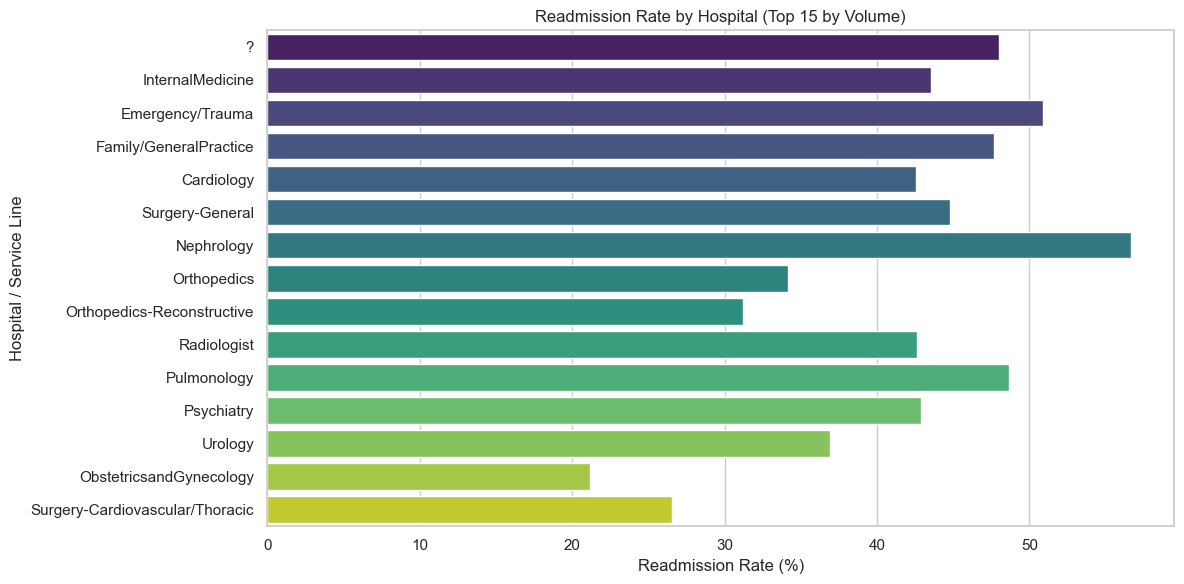

In [30]:
# Visualization 1: Readmission rate by hospital
q1_query = """
SELECT
    COALESCE(hospital, 'Unknown') AS hospital,
    ROUND(100.0 * AVG(CASE WHEN readmitted = 'Y' THEN 1 ELSE 0 END), 2) AS readmission_rate_pct,
    COUNT(*) AS total_admissions
FROM admissions
GROUP BY COALESCE(hospital, 'Unknown')
ORDER BY readmission_rate_pct DESC;
"""
q1 = pd.read_sql(q1_query, engine)

plt.figure(figsize=(12, 6))
top_hospitals = q1.nlargest(15, "total_admissions")
sns.barplot(
    data=top_hospitals,
    x="readmission_rate_pct",
    y="hospital",
    hue="hospital",
    dodge=False,
    legend=False,
    palette="viridis",
)
plt.title("Readmission Rate by Hospital (Top 15 by Volume)")
plt.xlabel("Readmission Rate (%)")
plt.ylabel("Hospital / Service Line")
plt.tight_layout()
plt.show()


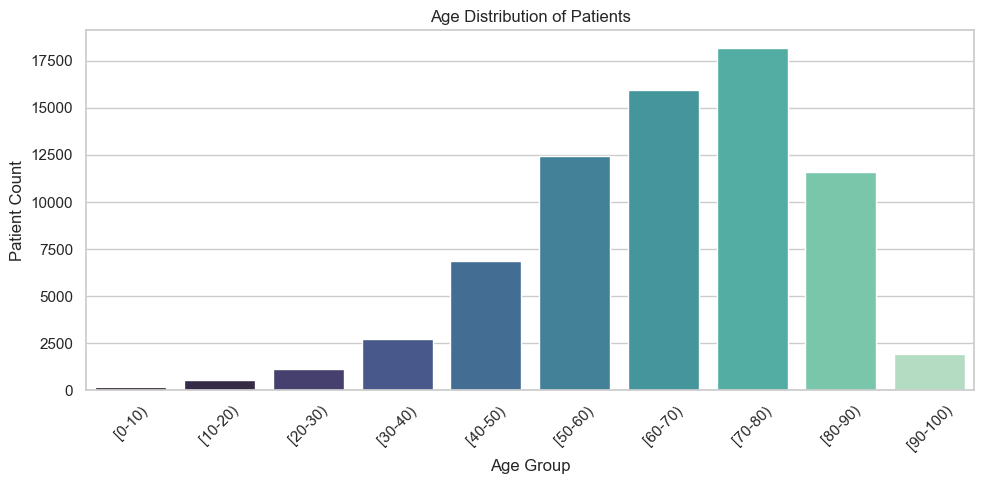

In [31]:
# Visualization 2: Age group distribution
q12_query = """
SELECT
    age AS age_group,
    COUNT(*) AS patient_count
FROM patients
GROUP BY age
ORDER BY age;
"""
q12 = pd.read_sql(q12_query, engine)

plt.figure(figsize=(10, 5))
sns.barplot(data=q12, x="age_group", y="patient_count", hue="age_group", dodge=False, legend=False, palette="mako")
plt.title("Age Distribution of Patients")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


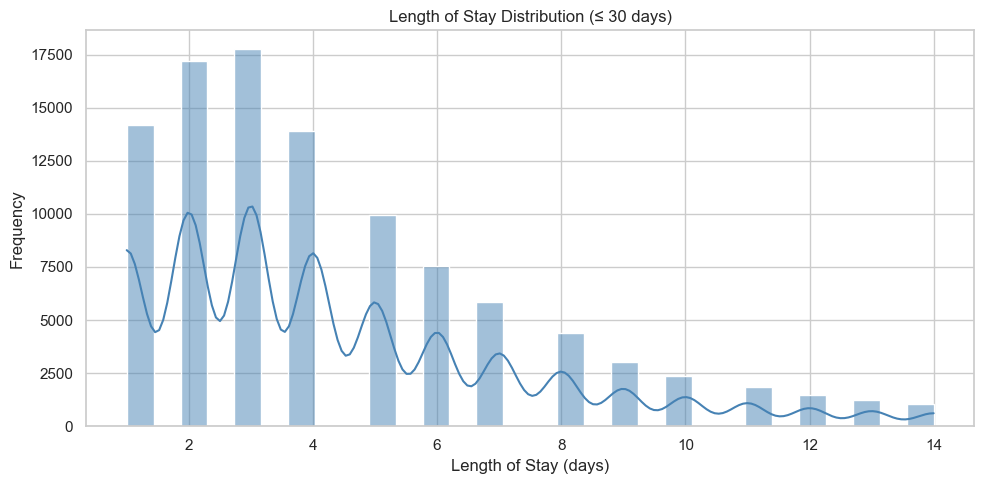

In [32]:
# Visualization 3: Length of stay distribution
los_df = pd.read_sql(
    """
    SELECT admission_id, length_of_stay_days
    FROM admissions
    WHERE length_of_stay_days IS NOT NULL AND length_of_stay_days <= 30
    """, engine,
)

plt.figure(figsize=(10, 5))
sns.histplot(los_df["length_of_stay_days"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Distribution (≤ 30 days)")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
